# Inspecting Koopman Eigenvalues and Eigenvectors

This notebook trains a **GraphKoopmanModel** and analyzes the learned finite-dimensional
Koopman operator matrix **K**. In Koopman operator theory, linear evolution in a lifted
latent space is governed by the spectrum of **K**:

- **Eigenvalues** describe how each mode grows, decays, or oscillates over time.
- **Eigenvectors** describe directions in latent space that evolve simply under **K**.

KoopmanGraph applies the same matrix to every node latent vector:

$$
z_{t+1} = z_t K^\top
$$

where each row of $z_t$ is one node's latent state. The operator is shared across
the graph; spatial structure enters through the encoder and decoder.

## What the spectrum tells us

In KoopmanGraph, one discrete step advances each node's latent row by the same matrix:

$$
z_{t+1} = z_t K^\top
$$

where $z_t \in \mathbb{R}^{d}$ is one node's latent vector and $K \in \mathbb{R}^{d \times d}$ is shared across nodes.

### Eigenmodes of $K$

If $K v = \lambda v$ for a column eigenvector $v$, define the row direction $u = v^\top$. A latent state aligned with $u$ updates simply:

$$
(\alpha u) K^\top = \alpha (K v)^\top = \alpha \lambda u
$$

So one step scales that component by $\lambda$. After $k$ steps its envelope grows or decays as $|\lambda|^k$. When $\lambda$ is complex, the mode also rotates in the complex plane (usually as a conjugate pair $\lambda, \bar{\lambda}$).

### Reading eigenvalues in the complex plane

- **Inside the unit circle** ($|\lambda| < 1$): stable, decaying mode.
- **Near the unit circle** ($|\lambda| \approx 1$): slow, persistent dynamics.
- **Outside the unit circle** ($|\lambda| > 1$): growing mode; often a sign the learned operator is amplifying errors during rollout.
- **On the real axis** ($\lambda \in \mathbb{R}$): monotonic growth or decay, no oscillation within the mode.
- **Off the real axis** ($\lambda \notin \mathbb{R}$): oscillatory behavior over multiple steps.

### From spectrum to graph behavior

Eigenvectors of $K$ are directions in **lifted latent space**, not node features. The encoder chooses that space and the decoder maps back to physical variables, so a Koopman mode must be read in two layers:

1. **Spectrum** — which time scales and stabilities the operator learned.
2. **Latent directions** — which coordinates in the lifted space participate in each mode.
3. **Decoder probe** — what spatial pattern in node features a small perturbation along that direction produces.

The plots below follow that workflow on the trained model.

In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    LossWeights,
    decode_mode_shapes,
)
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark

## Train a model on synthetic data

We use the same synthetic path-graph benchmark as the introductory tutorial, with forward
and rollout losses so **K** is encouraged to capture consistent latent dynamics.

In [2]:
data_sequence = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=20,
    num_timesteps=30,
    in_channels=3,
    topology="path",
    seed=42,
    initial_state="ones",
    decay_rate=0.99,
    diffusion_rate=0.1,
    noise_std=0.01,
)

in_channels = data_sequence.in_channels
hidden_channels = 64
latent_dim = 32
out_channels = in_channels

encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
decoder = GNNDecoder(latent_dim, hidden_channels, out_channels)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=0.1,
)

loss_weights = LossWeights(reconstruction=1.0, forward=1.0, rollout=1.0)
rollout_horizon = 8
EPOCHS = 40 if os.environ.get("PYTEST_CURRENT_TEST") else 150

torch.manual_seed(0)
history = model.fit(
    data_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=rollout_horizon,
)

print(f"Final training loss: {history.loss[-1]:.6f}")

Final training loss: 0.003062


## Compute the packaged Koopman spectrum

``model.spectrum()`` diagonalizes **K**, sorts modes by decreasing magnitude, and uses
``model.time_step`` to convert discrete eigenvalues into continuous-time growth rates
and frequencies. Column eigenvectors satisfy $K v = \lambda v$.

In [3]:
model.eval()
spectrum = model.spectrum()
K = model.koopman.K.detach().cpu()
eigvals = spectrum.eigenvalues.detach().cpu()
eigvecs = spectrum.eigenvectors.detach().cpu()
magnitudes = spectrum.magnitudes.detach().cpu()
growth_rates = spectrum.growth_rates.detach().cpu()
frequencies = spectrum.frequencies.detach().cpu()
order = torch.arange(model.latent_dim)

print(f"K shape: {tuple(K.shape)}")
print(f"Top-5 |lambda|: {magnitudes[:5].tolist()}")
print(f"Top-5 growth rates: {growth_rates[:5].tolist()}")
print(f"Top-5 frequencies: {frequencies[:5].tolist()}")

K shape: (32, 32)
Top-5 |lambda|: [1.0457757711410522, 1.0365166664123535, 1.0365166664123535, 1.03298819065094, 1.0329442024230957]
Top-5 growth rates: [0.4475897550582886, 0.3586573004722595, 0.3586573004722595, 0.3245575726032257, 0.32413172721862793]
Top-5 frequencies: [0.0, -0.02462936006486416, 0.02462936006486416, 0.0, 0.07233991473913193]


## Plot the eigenvalue spectrum

The unit circle marks the stability boundary for discrete-time linear dynamics. Modes
inside the circle decay; modes outside grow.

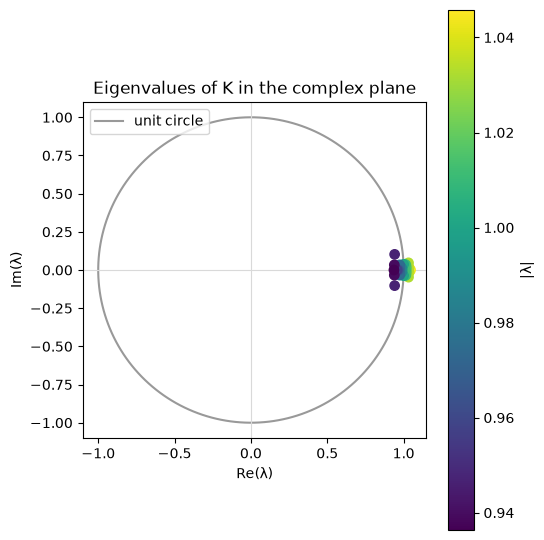

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color="0.6", linewidth=1.5, label="unit circle")

real = eigvals.real.numpy()
imag = eigvals.imag.numpy()
scatter = ax.scatter(real, imag, c=magnitudes.numpy(), cmap="viridis", s=45, zorder=3)
ax.axhline(0.0, color="0.85", linewidth=0.8)
ax.axvline(0.0, color="0.85", linewidth=0.8)
ax.set_xlabel("Re(λ)")
ax.set_ylabel("Im(λ)")
ax.set_title("Eigenvalues of K in the complex plane")
ax.set_aspect("equal", adjustable="box")
fig.colorbar(scatter, ax=ax, label="|λ|")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

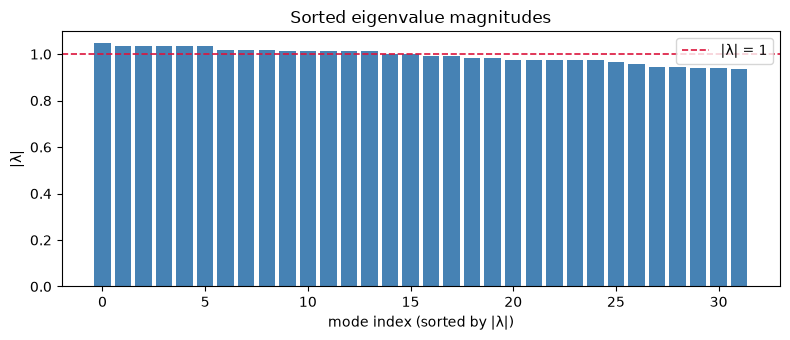

In [5]:
sorted_mags = magnitudes[order].numpy()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(np.arange(len(sorted_mags)), sorted_mags, color="steelblue")
ax.axhline(1.0, color="crimson", linestyle="--", linewidth=1.2, label="|λ| = 1")
ax.set_xlabel("mode index (sorted by |λ|)")
ax.set_ylabel("|λ|")
ax.set_title("Sorted eigenvalue magnitudes")
ax.legend()
fig.tight_layout()
plt.show()

## Inspect the operator matrix and leading eigenvectors

The heatmap of **K** shows cross-coupling between latent coordinates. Leading eigenvectors
highlight the dominant latent directions.

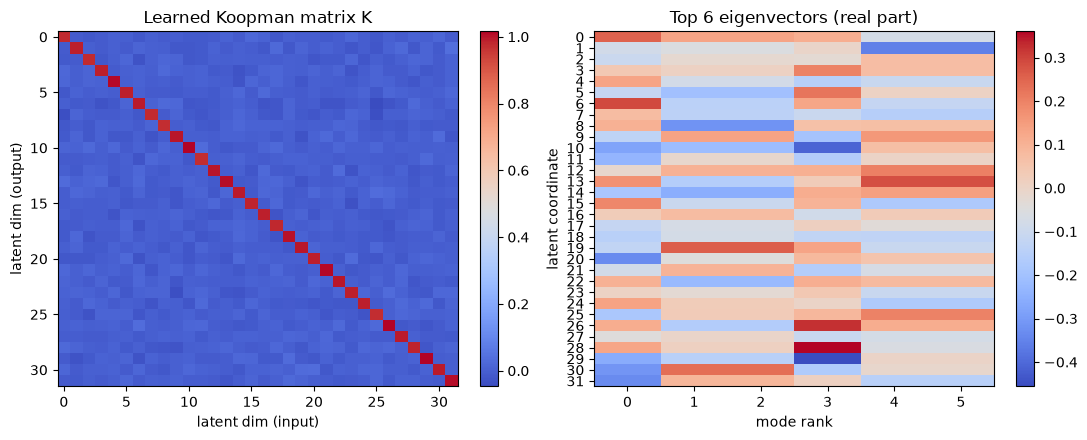

In [6]:
top_k = 6
top_vecs = eigvecs[:, order[:top_k]].real.numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].imshow(K.numpy(), aspect="auto", cmap="coolwarm")
axes[0].set_title("Learned Koopman matrix K")
axes[0].set_xlabel("latent dim (input)")
axes[0].set_ylabel("latent dim (output)")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(top_vecs, aspect="auto", cmap="coolwarm")
axes[1].set_title(f"Top {top_k} eigenvectors (real part)")
axes[1].set_xlabel("mode rank")
axes[1].set_yticks(range(latent_dim))
axes[1].set_ylabel("latent coordinate")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

fig.tight_layout()
plt.show()

## Mode time evolution: $|\lambda|^k$

For a mode with eigenvalue $\lambda$, one-step Koopman evolution scales its amplitude
by $|\lambda|$. Complex eigenvalues add oscillation through the phase of $\lambda^k$.

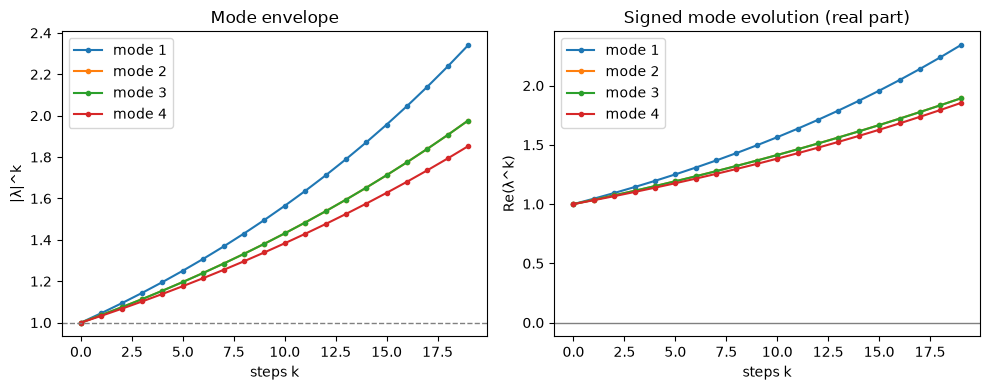

In [7]:
horizon = 20
steps = np.arange(horizon)
mode_ranks = [0, 1, 2, 3]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for rank in mode_ranks:
    lam = eigvals[order[rank]]
    envelope = lam.abs().numpy() ** steps
    axes[0].plot(steps, envelope, marker="o", markersize=3, label=f"mode {rank + 1}")

axes[0].axhline(1.0, color="0.5", linestyle="--", linewidth=1)
axes[0].set_xlabel("steps k")
axes[0].set_ylabel("|λ|^k")
axes[0].set_title("Mode envelope")
axes[0].legend()

for rank in mode_ranks:
    lam = eigvals[order[rank]]
    signal = (lam.numpy() ** steps).real
    axes[1].plot(steps, signal, marker="o", markersize=3, label=f"mode {rank + 1}")

axes[1].axhline(0.0, color="0.5", linewidth=1)
axes[1].set_xlabel("steps k")
axes[1].set_ylabel("Re(λ^k)")
axes[1].set_title("Signed mode evolution (real part)")
axes[1].legend()

fig.tight_layout()
plt.show()

## From latent modes to spatial patterns

To connect a latent eigenvector to physical node features, we apply a small perturbation
along the eigenvector to encoded states and decode the difference. This finite-difference
probe approximates how the decoder responds to that Koopman mode direction.

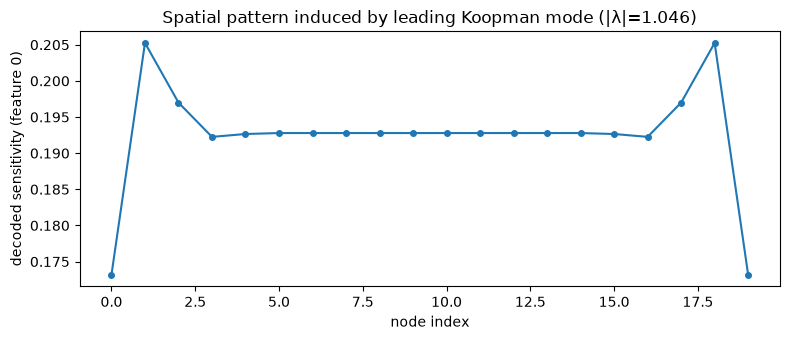

In [8]:
initial_graph = data_sequence[0]
alpha = 0.05
mode_rank = 0

mode_shapes = decode_mode_shapes(
    model,
    initial_graph,
    mode_indices=[mode_rank],
    perturbation=alpha,
)
spatial_pattern = mode_shapes[0].real

feature_idx = 0
nodes = np.arange(data_sequence.num_nodes)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(nodes, spatial_pattern[:, feature_idx].cpu().numpy(), marker="o", markersize=4)
ax.set_xlabel("node index")
ax.set_ylabel(f"decoded sensitivity (feature {feature_idx})")
ax.set_title(
    f"Spatial pattern induced by leading Koopman mode (|λ|={magnitudes[order[mode_rank]]:.3f})"
)
fig.tight_layout()
plt.show()

## Verify the Koopman eigenvector identity

For each eigenpair $(\lambda, v)$ we expect $K v \approx \lambda v$. Small
residuals indicate that **K** is well approximated by its spectral decomposition.

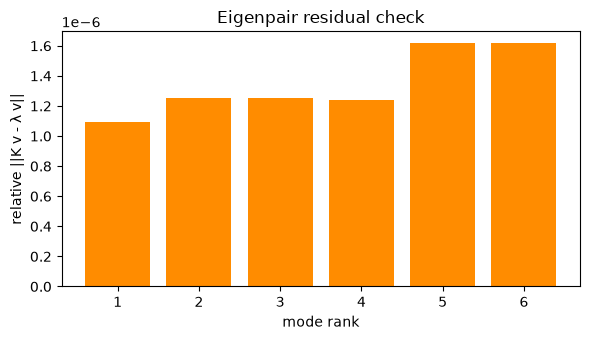

Relative residuals for top modes: ['1.09e-06', '1.25e-06', '1.25e-06', '1.24e-06', '1.62e-06', '1.62e-06']


In [9]:
residuals = []
K_complex = K.to(torch.complex64)
for idx in order[:top_k]:
    v = eigvecs[:, idx]
    lhs = K_complex @ v
    rhs = eigvals[idx] * v
    rel_err = (lhs - rhs).norm() / (rhs.norm() + 1e-12)
    residuals.append(rel_err.item())

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(np.arange(1, top_k + 1), residuals, color="darkorange")
ax.set_xlabel("mode rank")
ax.set_ylabel("relative ||K v - λ v||")
ax.set_title("Eigenpair residual check")
fig.tight_layout()
plt.show()

print("Relative residuals for top modes:", [f"{r:.2e}" for r in residuals])

## Takeaways

- The eigenvalue spectrum summarizes stability and time-scale structure of learned latent dynamics.
- Eigenvectors are coordinates in the lifted space; decode probes help relate them to graph features.
- For rollout quality, dominant modes with $|\lambda| \approx 1$ often carry persistent dynamics,
  while $|\lambda| \ll 1$ modes decay quickly.
- Compare this notebook with ``01_synthetic_graph.ipynb`` for the full train/predict workflow and
  with ``04_grid_attention.ipynb`` for attention-based encoders on grid data.